In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/msambare/fer2013


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import ToTensor
from torch import optim

import torchvision
from torchvision.transforms.functional import pil_to_tensor
from torchvision.transforms import ToPILImage
from torchvision import transforms

from torchvision import  datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os
import tqdm 

In [12]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.c1 = nn.Conv2d(1, 16, 5)
    self.c2 = nn.Conv2d(16, 16, 5)

    self.s1 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.c3 = nn.Conv2d(16,32,5)
    self.c4 = nn.Conv2d(32,32,5)

    self.s2 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1 = nn.Linear(1152,128)
    self.fc2 = nn.Linear(128,7)


  def forward(self, x):
    x = F.relu(self.c1(x))
    x = F.relu(self.c2(x))

    x = F.relu(self.s1(x))

    x = F.relu(self.c3(x))
    x = F.relu(self.c4(x))

    x = F.relu(self.s2(x))

    x = torch.flatten(x, 1)

    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x




In [13]:
torch.manual_seed(42)
model = Net()

In [14]:
train_path = "../input/datasets/msambare/fer2013/train"
test_path = "../input/datasets/msambare/fer2013/test"

classes = ["angry","disgust","fear","happy","neutral","sad", "surprise"]

In [15]:
# Train

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Grayscale(1),
    torchvision.transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4
)

# ========================

# Test
test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4
)

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    model.to('cuda')

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [18]:
num_epochs=30

all_accuracies = []
all_losses = []
for i in range(num_epochs):
    print(f"Epoch : [{i+1}/{num_epochs}]", end= ' | ')

    correct=0
    total=0
    running_loss = 0.0

    for batch_index, (data, targets) in enumerate(tqdm.tqdm(train_loader)):
        data, targets = data.to(device), targets.to(device)
        scores = model(data).to("cuda")

        loss = criterion(scores, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # computing accuracy & loss
        running_loss += loss.item()
        
        _, predictions = scores.max(1)
        correct += (predictions == targets).sum().item()
        total += targets.size(0)

    epoch_accuracy = correct/total
    epoch_loss = running_loss/len(train_loader)

    all_accuracies.append(epoch_accuracy)
    all_losses.append(epoch_loss)
    print(f"Accuracy : {epoch_accuracy:.4f} | Loss : {epoch_loss:.4f}")

Epoch : [1/30] | 

100%|██████████| 3589/3589 [00:18<00:00, 191.88it/s]


Accuracy : 0.3120 | Loss : 1.7098
Epoch : [2/30] | 

100%|██████████| 3589/3589 [00:18<00:00, 192.76it/s]


Accuracy : 0.4323 | Loss : 1.4713
Epoch : [3/30] | 

...

Accuracy : 0.7385 | Loss : 0.7042
Epoch : [29/30] | 

100%|██████████| 3589/3589 [00:21<00:00, 164.73it/s]


Accuracy : 0.7494 | Loss : 0.6864
Epoch : [30/30] | 

100%|██████████| 3589/3589 [00:22<00:00, 158.76it/s]

Accuracy : 0.7520 | Loss : 0.6764


In [19]:
all_data = []
all_targets = []
all_scores = []

for data, targets in tqdm.tqdm(test_loader):
    data, targets = data.to(device), targets.to(device)
    scores = model(data)

    all_data.append(data)
    all_targets.append(targets)
    all_scores.append(scores)

# Concatenate all batches
all_data = torch.cat(all_data)
all_targets = torch.cat(all_targets)
all_scores = torch.cat(all_scores)

100%|██████████| 898/898 [00:17<00:00, 51.24it/s]


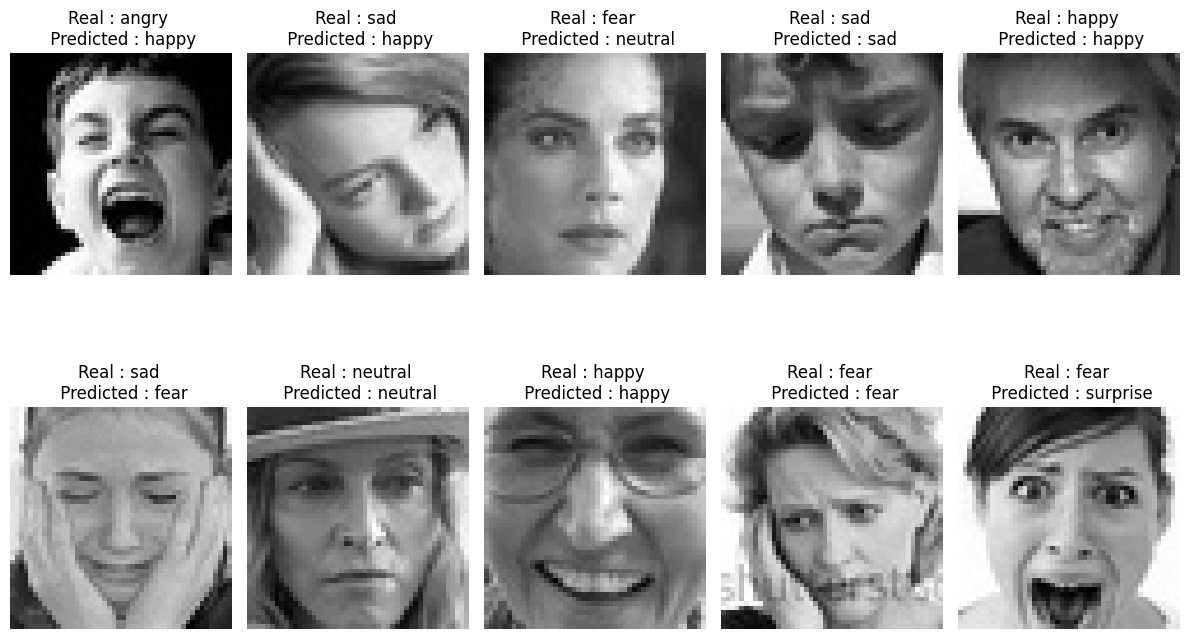

In [20]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(12,8))

for i in range(2):
    for j in range(5):
        idx = 5*i + j
        ax[i][j].imshow(all_data[idx].squeeze().cpu(), cmap='gray')
        ax[i][j].set_title(
            f"Real : {classes[all_targets[idx]]} \n Predicted : {classes[torch.argmax(all_scores[idx])]}"
        )
        ax[i][j].axis('off')

fig.tight_layout()
plt.show()

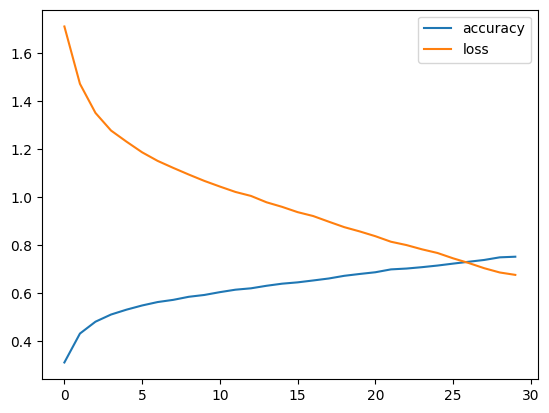

In [21]:
plt.plot(all_accuracies, label='accuracy')
plt.plot(all_losses, label='loss')
plt.legend(['accuracy','loss'])

plt.savefig('/kaggle/working/acc_loss.png')


In [25]:
torch.save(model.state_dict(), "/kaggle/working/model4.pkl")